In [3]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import hubble_fit
from hubble_fit import *

from hubble_utils import *
from hubble_likelihood import *
from hubble_plotting import *
from hubble_model import *
from hubble_completeness import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
prefix = 'sept19_sep8chisq_13k'
speed = 'production'
df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = load_pantheon_data()
df_agn = load_agn_data("results/data/sep23a_preview_chisq_lmc-4_N20w4000s1000t8co4ch4_1k.h5",
                       spectra_fit_csv=['results/data/sept6_newN1fit_frachost0_nc16_sep25b_preview_colin_reddened_sigmadm_logl.csv'],
                       zquery_csv='results/data/sep19_chisq_zquery.csv')

Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).


Reading quasars from HDF5: 100%|██████████| 1000/1000 [00:07<00:00, 126.43it/s]
/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Number of quasars loaded: 1000
Populating spectra fit data from: ['results/data/sept6_newN1fit_frachost0_nc16_sep25b_preview_colin_reddened_sigmadm_logl.csv']
Loading spectra fit CSV (0/1): results/data/sept6_newN1fit_frachost0_nc16_sep25b_preview_colin_reddened_sigmadm_logl.csv
Length of spectral fit file results/data/sept6_newN1fit_frachost0_nc16_sep25b_preview_colin_reddened_sigmadm_logl.csv: 13011
Number with apparent_mag_2500 > 0: 13011
Length of merged DataFrame: 1000
Populating column: f_host_4200
Adding new column f_host_4200 from spectralfit data
Populating column: f_host_2500
Adding new column f_host_2500 from spectralfit data
Populating column: f_host_5100
Adding new column f_host_5100 from spectralfit data
Populating column: ebv_fs
Adding new column ebv_fs from spectralfit data
Populating column: apparent_mag_2500_reddened
Adding new column apparent_mag_2500_reddened from spectralfit data
Populating column: apparent_mag_2500_reddened_err
Adding new column apparent_mag_2500_

/home/dutra/dev/eztaox/qvc/hubble_utils.py:189: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  xray_flux = df_matched['xray_flux'].replace(0, np.nan)
/home/dutra/dev/eztaox/qvc/hubble_utils.py:696: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_tau_band_RF_mean'] = np.log10(tau_band_RF_mean)
/home/dutra/dev/eztaox/qvc/hubble_utils.py:697: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

In [11]:
'ebv_fs' in df_agn.keys()

True

In [18]:
df_agn[df_agn['ebv_fs']==0][['sdss_name', 'ebv_wu']]

,sdss_name,ebv_wu
0,025234.20-001032.8,0.047527
1,025000.59-002431.0,0.048704
2,024958.84+011338.7,0.049780
4,024932.01+002248.3,0.045645
5,024918.81-002752.0,0.045046
...,...,...
774,212103.05-011139.1,0.041769
775,212025.78-001948.0,0.043201
776,211833.15-005408.1,0.047239
777,204106.09-003645.2,0.049461


In [4]:

cosmo_model_w0wa = "Flatw0waCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model_w0wa, completeness=True, use_full_cov=True, 
                    resume=f"results/dynesty_checkpoint/{prefix}/dynesty_checkpoint_{cosmo_model_w0wa}_joint_{speed}.save",
                    only_sna=False, speed=speed)
_, flat_samples_w0wa, model_labels_w0wa, dmag_corr_w0wa, _, _, debiased_residuals_w0wa = r

Running sampling with 9 parameters for cosmological model: Flatw0waCDM
object_id for m2500 > 25: ['024629.37+000735.3' '011911.24-001112.0']
Best alpha selected by CV: 0.0001
a (slope on mag_i)      = 1.046578 ± 0.003346
b (slope on alpha)      = 1.217357 ± 0.006396
d (quad term on mag_i)  = 0.013534 ± 0.001759
c_pivot (at pivots)     = 22.430897 ± 0.003199
c (intercept)           = -3.101976
R^2                     = 0.8951
Scatter (σ)             = 0.296 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
log tau UV RF mean: 2.8078
log tau UV RF pivot (weighted): 2.5739
log sigma0 mean: -0.6592
log sigma0 pivot (weighted): -0.6833
alpha_nu mean: -0.7858
alpha_nu pivot (weighted): nan
z mean: 1.589, calculated z pivot: 1.496
Checkpoint file: results/dynesty_checkpoint/dynesty_checkpoint_Flatw0waCDM_joint_production.save
Starting Hubble Fit with 12185 AGNs and 1657 SNes...


/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept19_sep8chisq_13k/dynesty_checkpoint_Flatw0waCDM_joint_production.save

Bayesian evidence logZ = -1358.70 ± 0.24

Highest-weight (posterior) sample:
  idx: 14580
  logl: -1331.178802474431
  weight: 0.00039915618275356506
  (preview) integrals[:10]: [0.41699684 0.46212277 0.17716648 0.4627847  0.25299121 0.60644655
 0.33635118 0.54661617 0.28455611 0.23995735]

Dynesty results stats:
  samples shape: (18660, 9)
  blobs shape: (18660, 2, 12185)
  weights max: 0.00039915618275356506
  effective samples (ESS): 3757.6500046457927
  resampled samples shape: (18660, 9)
  resampled blobs shape: (18660, 2, 12185)

Median parameters (equal-weight posterior):
[-19.24244634 -21.94270847   7.04665858  -3.12241814  -0.19214753
  72.68408276   0.57695675  -0.47237168 -17.83848575]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.8251851204288057
Saving plots to  plots/hubble//Flatw0waCDM_jo

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:1027: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  num_panels = num_rows * num_cols


Plotting Hubble diagram...


<string>:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Residuals saved to plots/hubble//Flatw0waCDM_joint_production/residuals.csv


<string>:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4 (sorted by residual, largest last):
	z: 2.76 | object_id: 1390664 | npca_qso: 0 | SDSS: 024328.86+003831.0 | RA: 40.87026 | DEC: 0.64196 | Residual: -5.5
	z: 1.65 | object_id: 1440703 | npca_qso: 0 | SDSS: 001342.45-002412.6 | RA: 3.42689 | DEC: -0.40351 | Residual: -4.6
	z: 0.83 | object_id: 1407814 | npca_qso: 1 | SDSS: 015500.27+004951.4 | RA: 28.75113 | DEC: 0.83096 | Residual: -4.5
	z: 1.07 | object_id: 1417953 | npca_qso: 0 | SDSS: 012528.84-000555.9 | RA: 21.37019 | DEC: -0.09888 | Residual: -4.4
	z: 0.27 | object_id: 1413536 | npca_qso: 1 | SDSS: 013809.54-010920.2 | RA: 24.53975 | DEC: -1.15563 | Residual: -4.3
	z: 0.19 | object_id: 1434162 | npca_qso: 2 | SDSS: 003511.48-004918.0 | RA: 8.79785 | DEC: -0.82167 | Residual: -4.3
	z: 1.39 | object_id: 1431736 | npca_qso: 2 | SDSS: 004222.09-003742.7 | RA: 10.59206 | DEC: -0.62854 | Residual: -4.3
	z: 2.86 | object_id: 1451784 | npca_qso: 2 | SD

Wrote result parameters LaTeX commands to plots/hubble/param_results.tex


[-0.26974147 -0.54510513 -0.99380543 ...  0.03886741  0.45146891
  0.21541936]


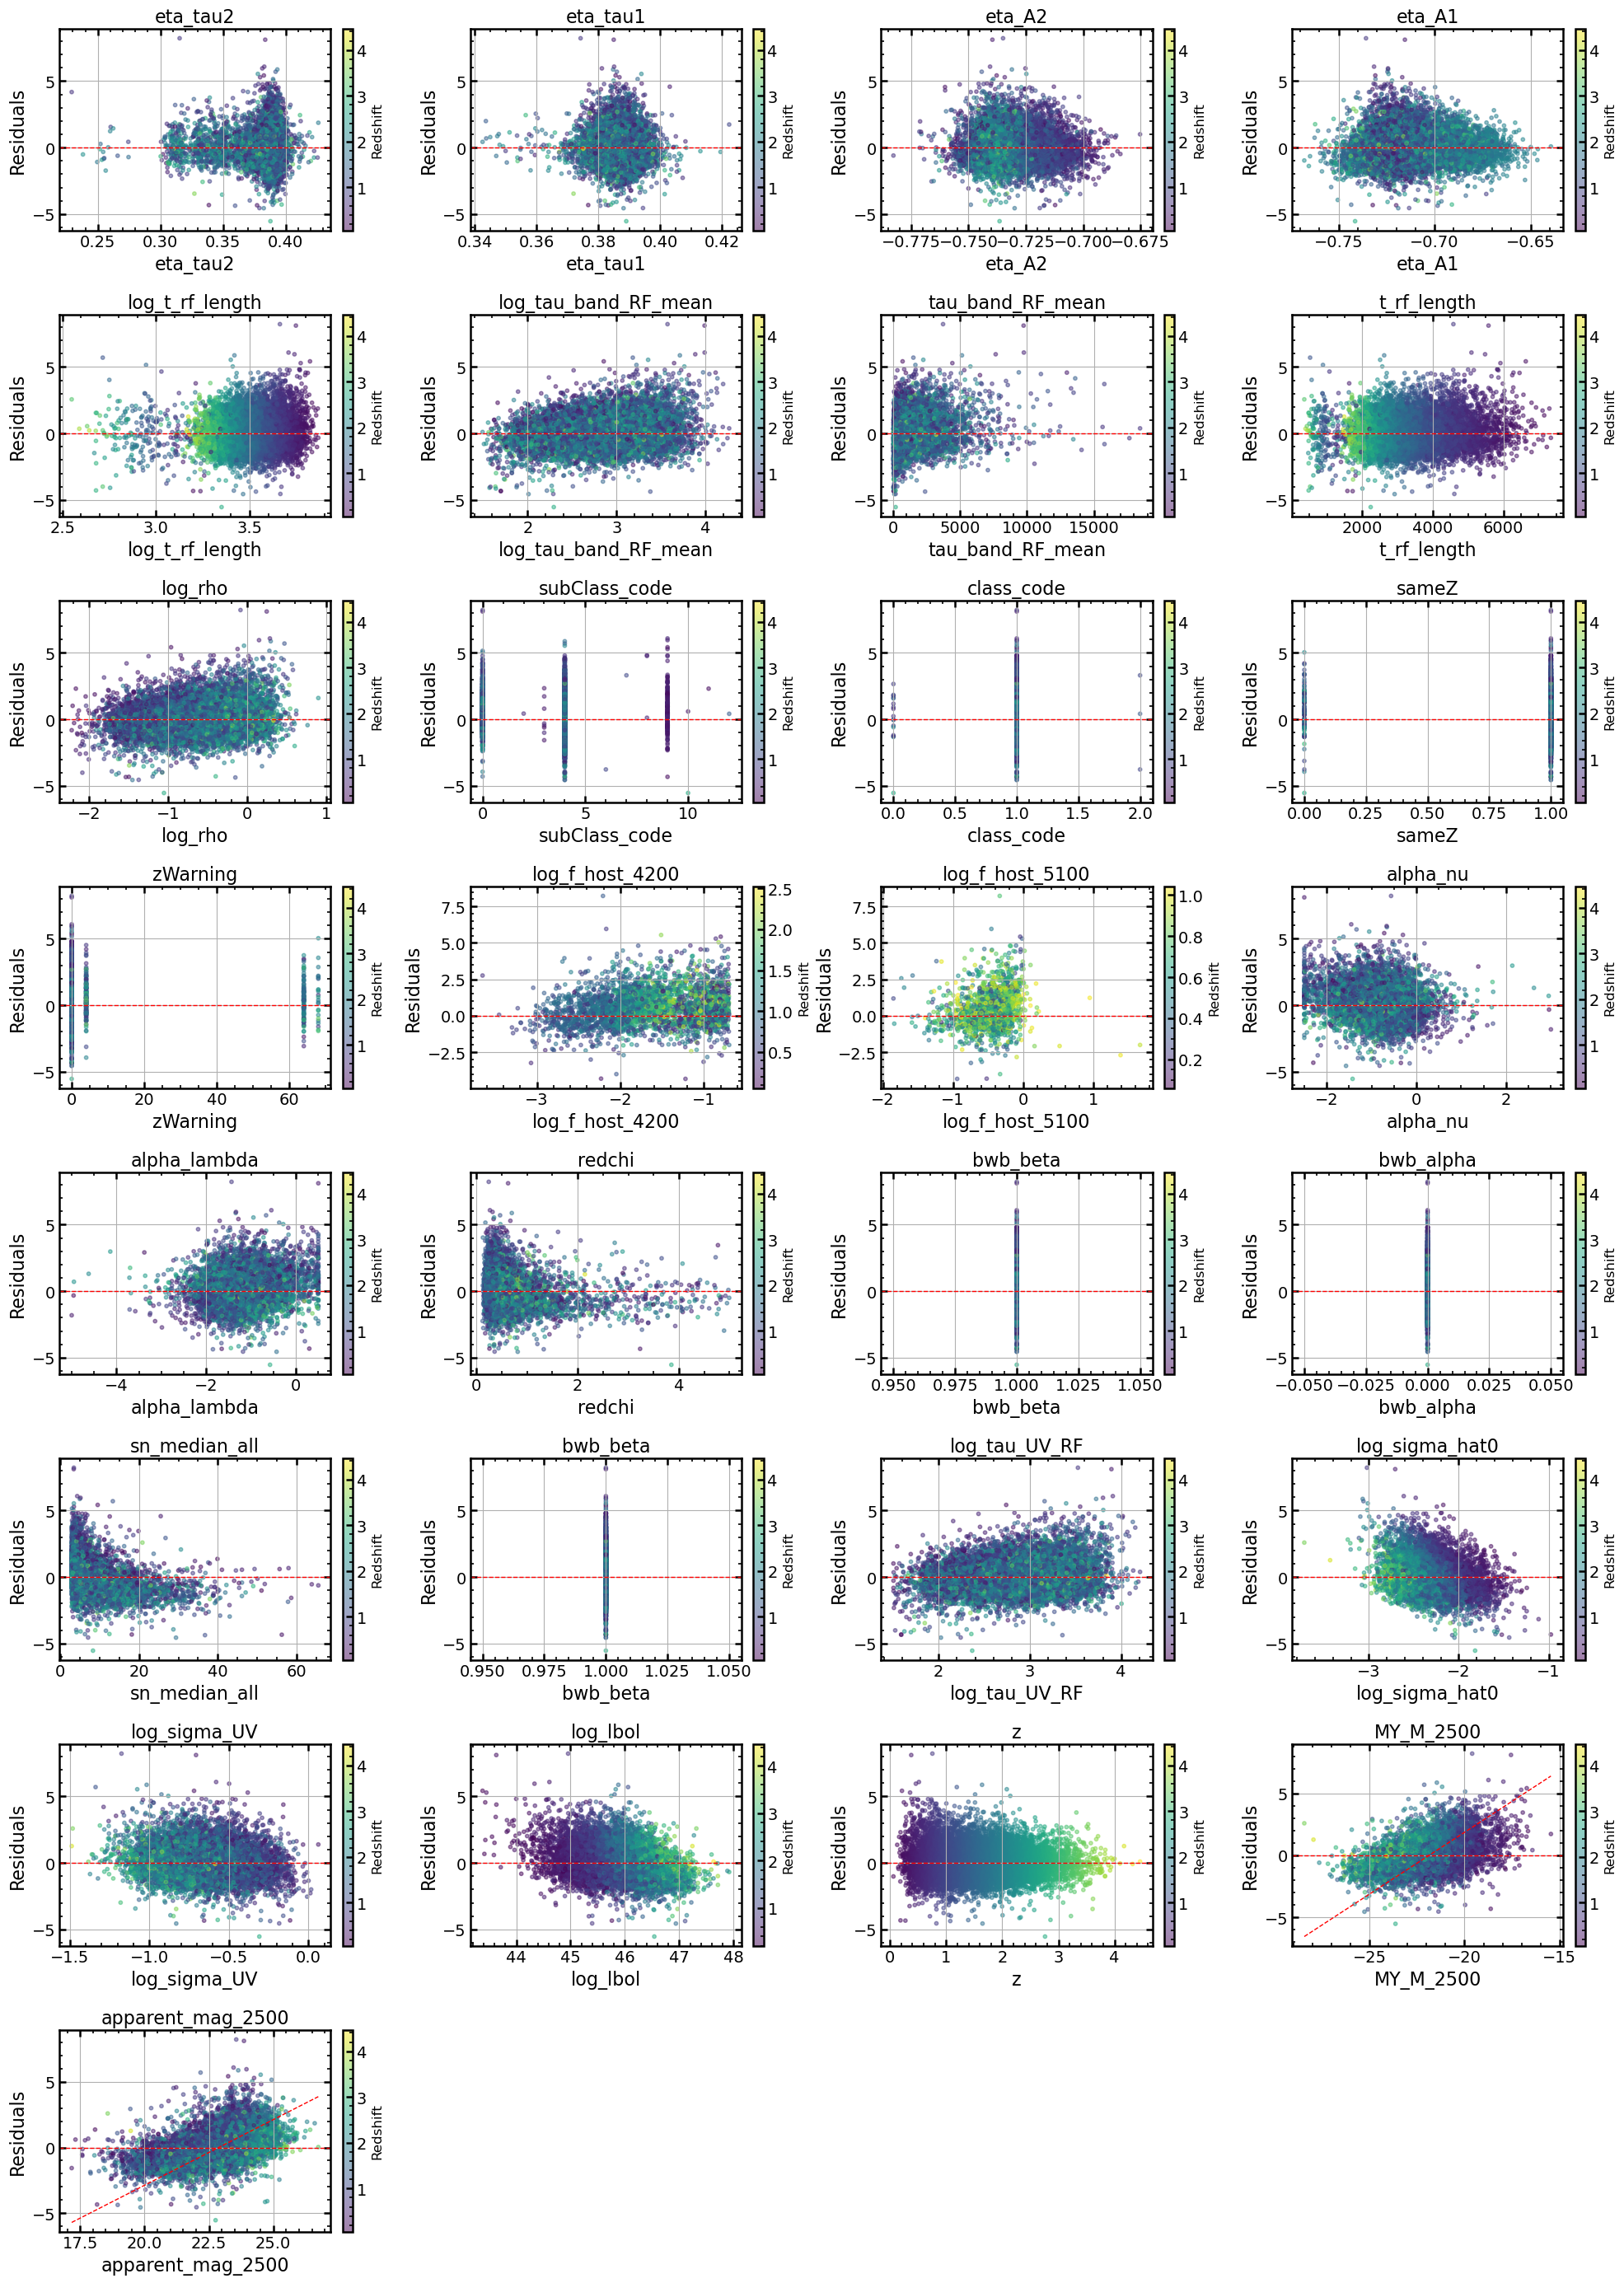

In [17]:
plot_full_residuals(df_agn, debiased_residuals_w0wa, flat_samples_w0wa, cosmo_model_w0wa, 0, debias=True, dms=dmag_corr_w0wa, plot_path='plots/hubble', show=True)

In [ ]:

cosmo_model_w = "FlatwCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model_w, completeness=True, use_full_cov=True, 
                     resume=f"results/dynesty_checkpoint/{prefix}/dynesty_checkpoint_{cosmo_model_w}_joint_{speed}.save",
                    only_sna=False, speed=speed)
_, flat_samples_w, _, dmag_corr, _, _, debiased_residuals_w = r

Running sampling with 8 parameters for cosmological model: FlatwCDM
object_id for m2500 > 25: ['024629.37+000735.3']
Best alpha selected by CV: 0.0001
a (slope on mag_i)      = 1.048097 ± 0.006170
b (slope on alpha)      = 1.216196 ± 0.011838
d (quad term on mag_i)  = 0.016309 ± 0.003252
c_pivot (at pivots)     = 22.409202 ± 0.005976
c (intercept)           = -4.273166
R^2                     = 0.8953
Scatter (σ)             = 0.300 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
mag centers: [16.14 16.42 16.7  16.98 17.26 17.54 17.82 18.1  18.38 18.66 18.94 19.22
 19.5  19.78 20.06 20.34 20.62 20.9  21.18 21.46 21.74 22.02 22.3  22.58
 22.86 23.14 23.42 23.7  23.98 24.26 24.54 24.82 25.1  25.38 25.66 25.94
 26.22 26.5  26.78 27.06 27.34 27.62 27.9  28.18 28.46 28.74 29.02 29.3
 29.58 29.86]
log tau UV RF mean: 2.8119
log tau UV RF pivot (weighted): 2.5699
log sigma0 mean: -0.6620
log sigma0 pivot (weighted): -0.6856
alpha_nu mean: -0.7884
alpha_nu pivot (weighted): nan

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept19_sep8chisq_4k/dynesty_checkpoint_FlatwCDM_joint_production.save

Bayesian evidence logZ = 4755.38 ± 0.22

Highest-weight (posterior) sample:
  idx: 12564
  logl: 4778.849087267037
  weight: 0.00038802778298869807
  (preview) integrals[:10]: [0.1238134  0.1386183  0.08443869 0.06859757 0.09837811 0.14915133
 0.0579019  0.10750716 0.09602357 0.11218172]

Dynesty results stats:
  samples shape: (16614, 8)
  blobs shape: (16614, 2, 3562)
  weights max: 0.00038802778298869807
  effective samples (ESS): 3677.5058513934723
  resampled samples shape: (16614, 8)
  resampled blobs shape: (16614, 2, 3562)

Median parameters (equal-weight posterior):
[-19.2437823  -22.03674561   7.20105472  -3.29537037  -0.17253552
  73.66612732   0.41688793  -1.24845763]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.8415284006088787
Saving plots to  plots/hubble//FlatwCDM_joint_production
Plotting 

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.49 | object_id: 1395787 | SDSS: 022914.13+010741.7 | RA: 37.30891 | DEC: 1.12826 | Residual: 4.7
	z: 1.19 | object_id: 1398455 | SDSS: 022159.81-005243.1 | RA: 35.49923 | DEC: -0.87864 | Residual: 5.6
	z: 1.65 | object_id: 1398944 | SDSS: 022045.29+011252.8 | RA: 35.18873 | DEC: 1.21468 | Residual: 4.0
	z: 0.44 | object_id: 1400643 | SDSS: 021605.09-001019.0 | RA: 34.02121 | DEC: -0.17194 | Residual: 4.4
	z: 0.84 | object_id: 1406881 | SDSS: 015802.36+002917.3 | RA: 29.50986 | DEC: 0.48816 | Residual: 4.1
	z: 0.41 | object_id: 1410524 | SDSS: 014638.32-004438.1 | RA: 26.65970 | DEC: -0.74393 | Residual: 4.6
	z: 0.27 | object_id: 1413536 | SDSS: 013809.54-010920.2 | RA: 24.53975 | DEC: -1.15563 | Residual: -4.2
	z: 1.98 | object_id: 1418942 | SDSS: 012223.42+004629.8 | RA: 20.59758 | DEC: 0.77497 | Residual: 4.6
	z: 0.74 | object_id: 1420387 | SDSS: 011812.12-010441.5 | RA: 19.55054 | DEC: -1.0

In [ ]:

cosmo_model_lambda = "FlatLambdaCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model_lambda, completeness=True, use_full_cov=True, 
                    resume=f"results/dynesty_checkpoint/{prefix}/dynesty_checkpoint_{cosmo_model_lambda}_joint_{speed}.save",
                    only_sna=False, speed=speed)
_, flat_samples_lambda, _, _, _, _, debiased_residuals_lambda = r

Running sampling with 7 parameters for cosmological model: FlatLambdaCDM
object_id for m2500 > 25: ['024629.37+000735.3']
Best alpha selected by CV: 0.0001
a (slope on mag_i)      = 1.048097 ± 0.006170
b (slope on alpha)      = 1.216196 ± 0.011838
d (quad term on mag_i)  = 0.016309 ± 0.003252
c_pivot (at pivots)     = 22.409202 ± 0.005976
c (intercept)           = -4.273166
R^2                     = 0.8953
Scatter (σ)             = 0.300 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
mag centers: [16.14 16.42 16.7  16.98 17.26 17.54 17.82 18.1  18.38 18.66 18.94 19.22
 19.5  19.78 20.06 20.34 20.62 20.9  21.18 21.46 21.74 22.02 22.3  22.58
 22.86 23.14 23.42 23.7  23.98 24.26 24.54 24.82 25.1  25.38 25.66 25.94
 26.22 26.5  26.78 27.06 27.34 27.62 27.9  28.18 28.46 28.74 29.02 29.3
 29.58 29.86]
log tau UV RF mean: 2.8119
log tau UV RF pivot (weighted): 2.5699
log sigma0 mean: -0.6620
log sigma0 pivot (weighted): -0.6856
alpha_nu mean: -0.7884
alpha_nu pivot (weighted)

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept19_sep8chisq_4k/dynesty_checkpoint_FlatLambdaCDM_joint_production.save

Bayesian evidence logZ = 4756.20 ± 0.22

Highest-weight (posterior) sample:
  idx: 11855
  logl: 4778.351136213723
  weight: 0.0004314080610032329
  (preview) integrals[:10]: [0.12029702 0.13566578 0.08108219 0.06438567 0.09654083 0.1435266
 0.05312624 0.10151918 0.09356814 0.10936957]

Dynesty results stats:
  samples shape: (15536, 7)
  blobs shape: (15536, 2, 3562)
  weights max: 0.0004314080610032329
  effective samples (ESS): 3420.6654005676137
  resampled samples shape: (15536, 7)
  resampled blobs shape: (15536, 2, 3562)

Median parameters (equal-weight posterior):
[-19.24164048 -22.05926823   7.30962433  -3.3378921   -0.1669507
  73.42054544   0.3484523 ]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.8462413337430826
Saving plots to  plots/hubble//FlatLambdaCDM_joint_production
Plotting full dy

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.49 | object_id: 1395787 | SDSS: 022914.13+010741.7 | RA: 37.30891 | DEC: 1.12826 | Residual: 4.8
	z: 1.19 | object_id: 1398455 | SDSS: 022159.81-005243.1 | RA: 35.49923 | DEC: -0.87864 | Residual: 5.7
	z: 1.65 | object_id: 1398944 | SDSS: 022045.29+011252.8 | RA: 35.18873 | DEC: 1.21468 | Residual: 4.0
	z: 0.44 | object_id: 1400643 | SDSS: 021605.09-001019.0 | RA: 34.02121 | DEC: -0.17194 | Residual: 4.5
	z: 0.84 | object_id: 1406881 | SDSS: 015802.36+002917.3 | RA: 29.50986 | DEC: 0.48816 | Residual: 4.1
	z: 0.41 | object_id: 1410524 | SDSS: 014638.32-004438.1 | RA: 26.65970 | DEC: -0.74393 | Residual: 4.7
	z: 0.27 | object_id: 1413536 | SDSS: 013809.54-010920.2 | RA: 24.53975 | DEC: -1.15563 | Residual: -4.1
	z: 1.98 | object_id: 1418942 | SDSS: 012223.42+004629.8 | RA: 20.59758 | DEC: 0.77497 | Residual: 4.6
	z: 0.74 | object_id: 1420387 | SDSS: 011812.12-010441.5 | RA: 19.55054 | DEC: -1.0

In [ ]:
cosmo_model_samples = {
    "Flatw0waCDM": flat_samples_w0wa,
    "FlatwCDM": flat_samples_w,
    "FlatLambdaCDM": flat_samples_lambda
}
cosmo_model_residuals = {
    "Flatw0waCDM": debiased_residuals_w0wa,
    "FlatwCDM": debiased_residuals_w,
    "FlatLambdaCDM": debiased_residuals_lambda
}

/tmp/ipykernel_33614/1053348476.py:431: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


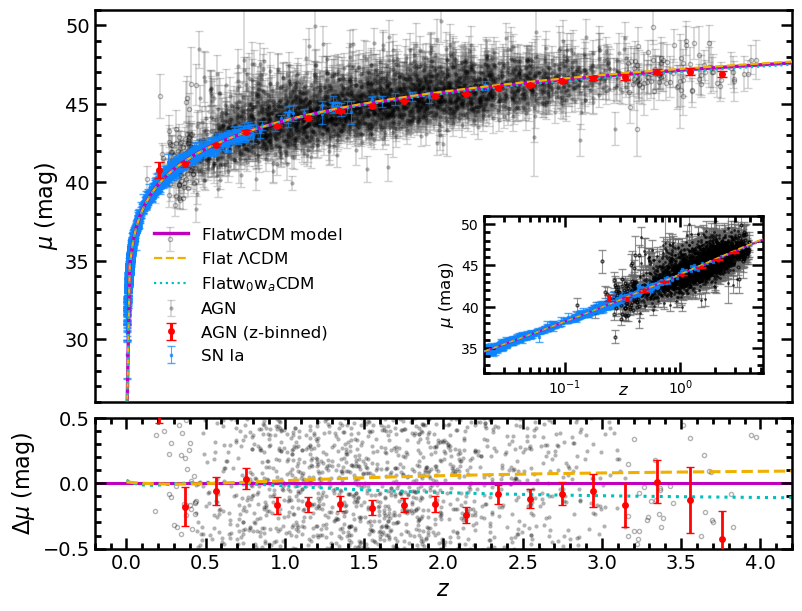

(array([ 0.93969911,  0.1613662 , -1.28212437, ..., -0.25663165,
        -0.17203143,  1.58828598], shape=(3562,)),
 array([45.58500666, 44.92784466, 42.62337879, ..., 43.95967437,
        44.95605927, 47.80873678], shape=(3562,)),
 array([0.73981005, 0.70179819, 0.57426711, ..., 0.6564861 , 0.78929889,
        1.16340073], shape=(3562,)))

In [ ]:
def plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model, z_pivot_agn, plot_path="plots/hubble/",
                show_binned_agn=True,
                debias=False, dms=None, show=False, completeness=True, show_true=False, verbose=True,
                cosmo_model_samples={}):
    """
    Hubble diagram (Pantheon+-style):
      • Model line + 68% band in magenta
      • Concordance ΛCDM in black
      • SN Ia in blue
      • AGN points + error bars (solid if 0.44<=z<=3.16 else open)
      • Main: AGN binned in linear z
      • Inset: AGN binned in log z (matches inset x-scale)
    If residuals_2 is provided, the residuals panel overlays a solid line of (residuals - residuals_2).
    Returns: residuals, mu_pred_median, mu_pred_std
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from astropy.cosmology import FlatLambdaCDM, FlatwCDM, Flatw0waCDM
    from scipy.ndimage import uniform_filter1d
    # Ensure your project provides these:
    # from your_module import FlatwpwaCDM, M_model_agn, M_model_agn_err, get_model_params, make_dm_function
    # (FlatwpwaCDM expected if using 'FlatwpwaCDM')

    # --- Labels ---
    if   cosmo_model == 'FlatwCDM':      label = r"Flat$w$CDM model"
    elif cosmo_model == 'Flatw0waCDM':   label = r"Flat$w_0w_a$CDM model"
    elif cosmo_model == 'FlatLambdaCDM': label = r"Flat$\Lambda$CDM model"
    elif cosmo_model == 'FlatwpwaCDM':   label = r"Flat$w_p\!-\!w_a$CDM model"
    else:
        raise ValueError("Invalid cosmology model.")

    # --- Thinning for speed (cap to ~500 samples) ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    z_grid = np.linspace(1e-4, 5.2, 250)

    # --- Parameter bookkeeping ---
    _, model_labels, _ = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Small helper: μ_model(z | params) ---
    def _mu_model(model_name, params_dict, z, zp):
        if model_name == 'FlatwCDM':
            return FlatwCDM(H0=params_dict['H0'], Om0=params_dict['Om0'], w0=params_dict['w0']).distmod(z).value
        elif model_name == 'Flatw0waCDM':
            return Flatw0waCDM(H0=params_dict['H0'], Om0=params_dict['Om0'],
                               w0=params_dict['w0'], wa=params_dict['wa']).distmod(z).value
        elif model_name == 'FlatLambdaCDM':
            return FlatLambdaCDM(H0=params_dict['H0'], Om0=params_dict['Om0']).distmod(z).value
        elif model_name == 'FlatwpwaCDM':
            return FlatwpwaCDM(H0=params_dict['H0'], Om0=params_dict['Om0'],
                               wp=params_dict['wp'], wa=params_dict['wa'], zp=zp).distmod(z).value
        else:
            raise ValueError("Invalid cosmology model for _mu_model().")

    # --- Cosmology band on grid from posterior samples ---
    mu_models = np.array([
        _mu_model(
            cosmo_model,
            {k: s[param_indices[k]] for k in model_labels},
            z_grid, z_pivot_agn
        )
        for s in flat_samples
    ])
    mu_model_16th   = np.percentile(mu_models, 16, axis=0)
    mu_model_median = np.percentile(mu_models, 50, axis=0)
    mu_model_84th   = np.percentile(mu_models, 84, axis=0)

    # Median params (also used later)
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}

    # --- Predicted AGN μ per object ---
    m_obs = df_agn['apparent_mag_2500'].values
    mu_pred_samples = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        agn_params_arr = agn_model_pack_params(sample_params)
        agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(df_agn)

        predicted_M2500 = M_model_agn(agn_params_arr, agn_obs_arr, agn_pivot_arr)
        predicted_M2500_err = M_model_agn_err(agn_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
        mu_pred_samples.append(m_obs - predicted_M2500)
    mu_pred_samples = np.array(mu_pred_samples)

    # De-bias (assumes your make_dm_function clips to grid, no extrapolation)
    if debias:
        dm_interp = make_dm_function(m_obs, df_agn['z'], dms, method='linear')
        pts = np.column_stack([df_agn['z'].values, m_obs])
        mu_pred_samples -= dm_interp(pts)

    mu_pred_median = np.percentile(mu_pred_samples, 50, axis=0)
    mu_pred_16th   = np.percentile(mu_pred_samples, 16, axis=0)
    mu_pred_84th   = np.percentile(mu_pred_samples, 84, axis=0)

    # Per-object uncertainty (for yerr)
    agn_params_arr = agn_model_pack_params(results)
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(df_agn)
    predicted_M2500 = M_model_agn(agn_params_arr, agn_obs_arr, agn_pivot_arr)
    predicted_M2500_err = M_model_agn_err(agn_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)

    mu_pred_std = np.sqrt(
        df_agn['apparent_mag_2500_err'].values**2 +
        (0.055 * df_agn["z"].values)**2 +
        predicted_M2500_err**2
    )

    # Residuals (vs. median μ_model)
    mu_interp = np.interp(df_agn["z"].values, z_grid, mu_model_median)
    residuals = mu_pred_median - mu_interp

    # ----------------- BINNING -----------------
    def _weighted_bin_stats(z, y, w, bins, *, min_count=3, center='weighted', weight_mode='ivar'):
        """
        weight_mode:
        'ivar' -> w = 1/sigma^2  (SEM = 1/sqrt(sum w))
        'freq' -> frequency/importance weights (SEM = s_w / sqrt(n_eff))
        """
        z, y, w = map(np.asarray, (z, y, w))
        mfin = np.isfinite(z) & np.isfinite(y) & np.isfinite(w) & (w > 0)
        z, y, w = z[mfin], y[mfin], w[mfin]

        # np.digitize: for right=False, bins are (bins[i-1], bins[i]].
        idx = np.digitize(z, bins, right=False)

        zs, means, sems, counts = [], [], [], []
        for i in range(1, len(bins)):
            m = (idx == i)
            if m.sum() >= min_count:
                zi, yi, wi = z[m], y[m], w[m]
                wsum = wi.sum()
                ybar = np.sum(wi * yi) / wsum
                means.append(ybar)
                counts.append(m.sum())

                if weight_mode == 'ivar':
                    sem = np.sqrt(1.0 / wsum)
                else:
                    # Weighted SD (unbiased-ish) and Kish n_eff
                    n_eff = (wsum**2) / np.sum(wi**2)
                    # Cochran-style weighted variance
                    denom = wsum - (np.sum(wi**2) / wsum)
                    if denom <= 0:
                        sem = np.nan
                    else:
                        s2w = np.sum(wi * (yi - ybar)**2) / denom
                        sem = np.sqrt(s2w / n_eff)
                sems.append(sem)

                if center == 'weighted':
                    zs.append(np.average(zi, weights=wi))
                elif center == 'geom':
                    zs.append(np.sqrt(bins[i-1] * bins[i]))
                else:  # 'mid'
                    zs.append(0.5 * (bins[i-1] + bins[i]))

        return np.asarray(zs), np.asarray(means), np.asarray(sems)

    # Weights for AGN
    w = 1.0 / np.square(mu_pred_std)

    # Linear-z bins for MAIN & RESIDUALS panel
    dz   = 0.2
    zmax_main = 3.8
    bins_linear = np.arange(0.05, zmax_main + dz + 1e-9, dz)
    z_lin, mu_lin_mean, mu_lin_sem = _weighted_bin_stats(
        df_agn["z"].values, mu_pred_median, w, bins_linear, min_count=3, center='weighted'
    )

    # NEW: binned residuals (linear-z), used in residual panel
    z_res_lin, resid_lin_mean, resid_lin_sem = _weighted_bin_stats(
        df_agn["z"].values, residuals, w, bins_linear, min_count=3, center='weighted'
    )

    # Log-z bins for INSET (match inset xscale='log')
    zpos = df_agn["z"].values[df_agn["z"].values > 0]
    zmin_inset = max(0.02, float(np.min(zpos))) if zpos.size else 0.02
    zmax_inset = 3.8
    bins_per_decade = 6
    decades = np.log10(zmax_inset) - np.log10(zmin_inset)
    n_bins_log = max(1, int(np.ceil(decades * bins_per_decade)))
    bins_log = np.logspace(np.log10(zmin_inset), np.log10(zmax_inset), n_bins_log + 1)
    z_log, mu_log_mean, mu_log_sem = _weighted_bin_stats(
        df_agn["z"].values, mu_pred_median, w, bins_log, min_count=3, center='weighted'
    )

    # ======== Plot ========
    fig = plt.figure(figsize=(9, 7))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.06)
    ax = fig.add_subplot(gs[0])
    ax.set_ylim(26, 51)
    ax.set_xlim(-0.2, 4.2)
    inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=1.5)
    ax_resid = fig.add_subplot(gs[1], sharex=ax)

    # Solid vs open AGN markers by z (both main and inset)
    mask_in  = df_agn["z"].between(0.44, 3.16)
    mask_out = ~mask_in

    # ---------- Inset (log-z) ----------
    inset_ax.set_xscale('log')

    # AGN (inside)
    inset_ax.errorbar(
        df_agn["z"][mask_in], mu_pred_median[mask_in], yerr=mu_pred_std[mask_in],
        fmt='o', linestyle='none', markersize=2,
        mfc="black", mec="none",
        ecolor="#666666", elinewidth=0.8,
        alpha=0.7, zorder=1, label="AGN"
    )
    # AGN (outside, open)
    inset_ax.errorbar(
        df_agn["z"][mask_out], mu_pred_median[mask_out], yerr=mu_pred_std[mask_out],
        fmt='o', linestyle='none', markersize=2, mfc='none', mec="k", alpha=0.70,
        ecolor="#666666", elinewidth=0.8, zorder=1
    )

    # INSET: log-binned AGN
    if show_binned_agn:
        inset_ax.errorbar(
            z_log, mu_log_mean, yerr=mu_log_sem,
            fmt='o', linestyle='none',
            markersize=3, mfc='red', mec='none',
            ecolor='red', elinewidth=2.2, capsize=3.5,
            alpha=0.98, zorder=14, label="AGN (z-binned, log)"
        )

    # SN Ia
    inset_ax.errorbar(
        df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"],
        fmt='s', markersize=2, color="#0A84FF", linestyle='none', lw=0.8, alpha=0.7, zorder=1, label="SN Ia"
    )

    # Model + band
    inset_ax.plot(z_grid, mu_model_median, color="m", lw=1.4, alpha=1.0, zorder=5, label=label)
    inset_ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="m", alpha=0.22, zorder=4)

    # Flat Lambda CDM
    # mu_conc = FlatLambdaCDM(H0=70, Om0=0.3).distmod(z_grid).value
    # inset_ax.plot(z_grid, mu_conc, color="#F0B000", lw=1.2, ls='--', zorder=5, alpha=1.0, label=r"Concordance $\Lambda$CDM")


    inset_ax.set_xlim(0.02, 5.2)
    inset_ax.set_ylim(32, 51)
    inset_ax.set_xlabel(r"$z$", fontsize=12, labelpad=-10)
    inset_ax.set_ylabel(r"$\mu$ (mag)", fontsize=12)
    inset_ax.tick_params(axis='both', which='major', labelsize=10)

    # ---------- Main plot ----------
    # AGN (inside)
    ax.errorbar(
        df_agn["z"][mask_in], mu_pred_median[mask_in], yerr=mu_pred_std[mask_in],
        fmt='o', linestyle='none', markersize=3,
        mfc="black", mec="none",
        ecolor="#666666", elinewidth=1.1,
        alpha=0.3, zorder=0, label="AGN"
    )
    # AGN (outside, open)
    ax.errorbar(
        df_agn["z"][mask_out], mu_pred_median[mask_out], yerr=mu_pred_std[mask_out],
        fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.3,
        ecolor="#666666", elinewidth=1.1, zorder=0
    )

    # MAIN: linear-binned AGN
    if show_binned_agn:
        ax.errorbar(
            z_lin, mu_lin_mean, yerr=mu_lin_sem,
            fmt='o', linestyle='none',
            markersize=5, mfc='red', mec='none',
            ecolor='red', elinewidth=2.2, capsize=3.5,
            alpha=0.98, zorder=14, label="AGN (z-binned)"
        )

    # SN Ia
    ax.errorbar(
        df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"],
        fmt='s', markersize=2, color="#0A84FF", linestyle='none', lw=0.8, alpha=0.7, zorder=1, label="SN Ia"
    )

    # Model + 68% band
    ax.plot(z_grid, mu_model_median, color="m", lw=2.4, alpha=1.0, zorder=5, label=label)
    ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="m", alpha=0.25, zorder=4)

    # Survey magnitude limit (shade above)
    if completeness and not debias:
        agn_params_arr = agn_model_pack_params(results)
        agn_obs_med = dict(
            log_sigma_UV    = float(np.median(df_agn['log_sigma_UV'].values)) * np.ones_like(z_grid),
            log_sigma_UV_err = float(np.median(df_agn['log_sigma_UV_err'].values)) * np.ones_like(z_grid),
            log_tau_UV_RF = float(np.median(df_agn['log_tau_UV_RF'].values)) * np.ones_like(z_grid),
            log_tau_UV_RF_err = float(np.median(df_agn['log_tau_UV_RF_err'].values)) * np.ones_like(z_grid),
            alpha_nu     = float(np.median(df_agn['alpha_nu'].values)) * np.ones_like(z_grid),
            alpha_nu_err = float(np.median(df_agn['alpha_nu_err'].values)) * np.ones_like(z_grid),
            cov_log_sigma_UV_log_tau_UV_RF = float(np.median(df_agn['cov_log_sigma_UV_log_tau_UV_RF'].values)) * np.ones_like(z_grid),

            log_tau_UV_RF_std_psd = float(np.median(df_agn['log_tau_UV_RF_std_psd'].values)) * np.ones_like(z_grid),
            log_sigma_UV_std_psd = float(np.median(df_agn['log_sigma_UV_std_psd'].values)) * np.ones_like(z_grid),
            log_sigma_UV_log_tau_UV_RF_cov_psd = float(np.median(df_agn['log_sigma_UV_log_tau_UV_RF_cov_psd'].values)) * np.ones_like(z_grid),
        )
        agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(agn_obs_med)

        M_med_grid = np.median([
            M_model_agn(agn_params_arr, agn_obs_arr, agn_pivot_arr)
            for s in flat_samples
        ], axis=0)

        m_lim = 24.0
        mu_lim = m_lim - M_med_grid
        ax.fill_between(z_grid, mu_lim, 60, color="red", alpha=0.15, zorder=2, label="< 50% complete")
        inset_ax.fill_between(z_grid, mu_lim, 60, color="red", alpha=0.12, zorder=2, label="< 50% complete")

    # Flat ΛCDM
    if 'FlatLambdaCDM' in cosmo_model_samples:
        flat_samples_lambda = cosmo_model_samples['FlatLambdaCDM']
        flat_samples_lambda = flat_samples_lambda[::thin_factor]

        _, model_labels_lambda, _ = get_model_params('FlatLambdaCDM')
        param_indices_lambda = {name: model_labels_lambda.index(name) for name in model_labels_lambda}
        mu_model_lambda = np.array([
            _mu_model(
                'FlatLambdaCDM',
                {k: s[param_indices_lambda[k]] for k in model_labels_lambda},
                z_grid, z_pivot_agn)
        for s in flat_samples_lambda
        ])
        mu_model_16th_lambda   = np.percentile(mu_model_lambda, 16, axis=0)
        mu_model_median_lambda = np.percentile(mu_model_lambda, 50, axis=0)
        mu_model_84th_lambda   = np.percentile(mu_model_lambda, 84, axis=0)

        ax.plot(z_grid, mu_model_median_lambda, color="#F0B000", lw=1.6, ls='--', alpha=1.0, zorder=5, label=r"Flat $\Lambda$CDM")
        #ax.fill_between(z_grid, mu_model_16th_lambda, mu_model_84th_lambda, color="#F0B000", alpha=0.25, zorder=4)
        inset_ax.plot(z_grid, mu_model_median_lambda, color="#F0B000", lw=1.2, ls='--', alpha=1.0, zorder=5)

    # Flatw0waCDM
    if 'Flatw0waCDM' in cosmo_model_samples:
        flat_samples_w0wa = cosmo_model_samples['Flatw0waCDM']
        flat_samples_w0wa = flat_samples_w0wa[::thin_factor]

        _, model_labels_w0wa, _ = get_model_params('Flatw0waCDM')
        param_indices_w0wa = {name: model_labels_w0wa.index(name) for name in model_labels_w0wa}
        mu_model_w0wa = np.array([
            _mu_model(
                'Flatw0waCDM',
                {k: s[param_indices_w0wa[k]] for k in model_labels_w0wa},
                z_grid, z_pivot_agn)
        for s in flat_samples_w0wa
        ])
        mu_model_16th_w0wa   = np.percentile(mu_model_w0wa, 16, axis=0)
        mu_model_median_w0wa = np.percentile(mu_model_w0wa, 50, axis=0)
        mu_model_84th_w0wa   = np.percentile(mu_model_w0wa, 84, axis=0)
        
        ax.plot(z_grid, mu_model_median_w0wa, color="c", ls='dotted', alpha=1.0, lw=1.6, zorder=5, label=r"Flatw$_0$w$_a$CDM")
        #ax.fill_between(z_grid, mu_model_16th_w0wa, mu_model_84th_w0wa, color="c", alpha=0.25, zorder=5)
        inset_ax.plot(z_grid, mu_model_median_w0wa, color="c", ls='dotted', lw=1.2, alpha=1.0, zorder=5)
    
    # Labels
    ax.set_ylabel(r"$\mu$ (mag)")
    ax.set_xlabel(r"$z$")

    # ---------- Residuals panel ----------
    # AGN residuals (inside)
    ax_resid.plot(
        df_agn["z"][mask_in], residuals[mask_in],
        'o', markersize=3, mfc="black", mec="none", alpha=0.3, zorder=0, label="AGN residuals"
    )
    # AGN residuals (outside)
    ax_resid.plot(
        df_agn["z"][mask_out], residuals[mask_out],
        'o', markersize=3, mfc='none', mec="k", alpha=0.3, zorder=0, label="AGN residuals (out)"
    )
    # Zero line
    ax_resid.axhline(0.0, color="m", lw=2.2, zorder=1)

    # NEW: binned residuals in red (points + thin connecting line)
    if z_res_lin.size:
        ax_resid.errorbar(
            z_res_lin, resid_lin_mean, yerr=resid_lin_sem,
            fmt='o', linestyle='none', markersize=5,
            mfc='red', mec='none', ecolor='red', elinewidth=2.0, capsize=3.0,
            alpha=0.98, zorder=15, label="Binned AGN residuals"
        )
        #ax_resid.plot(z_res_lin, resid_lin_mean, lw=1.2, color='red', alpha=0.9, zorder=14)


    # Optional: line for (residuals - residuals_2) using median params of each model
    if 'Flatw0waCDM' in cosmo_model_samples:
        z_grid_fine = np.linspace(1e-4, 5.2, 500)
        results_w0wa = {key: np.median(flat_samples_w0wa[:, i]) for i, key in enumerate(model_labels_w0wa)}

        mu_model_1 = _mu_model(cosmo_model, results,   z_grid_fine, z_pivot_agn)
        mu_model_w0wa = _mu_model('Flatw0waCDM', results_w0wa, z_grid_fine, z_pivot_agn)
        ax_resid.plot(z_grid_fine, mu_model_w0wa - mu_model_1, lw=2.2, color="c", ls='dotted', alpha=1.0, label=r"Flatw$_0$w$_a$CDM $\Delta$μ")
    if 'FlatLambdaCDM' in cosmo_model_samples:
        z_grid_fine = np.linspace(1e-4, 5.2, 500)
        _, model_labels_lambda, _ = get_model_params(cosmo_model_lambda)
        results_lambda = {key: np.median(flat_samples_lambda[:, i]) for i, key in enumerate(model_labels_lambda)}

        mu_model_1 = _mu_model(cosmo_model, results,   z_grid_fine, z_pivot_agn)
        mu_model_lambda = _mu_model('FlatLambdaCDM', results_lambda, z_grid_fine, z_pivot_agn)
        ax_resid.plot(z_grid_fine, mu_model_lambda - mu_model_1, lw=2.2, color="#F0B000", ls='--', alpha=1.0,)

    ax_resid.set_ylabel(r"$\Delta\mu$ (mag)")
    ax_resid.set_xlabel(r"$z$")
    ax_resid.set_ylim(-.5, .5)
    #ax_resid.legend(frameon=True, loc="upper left", fontsize=10)

    for axi in (ax, inset_ax, ax_resid):
        axi.minorticks_on()
        axi.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True, width=2)
        axi.tick_params(axis='both', which='major', direction='in', length=8, top=True, right=True)

    # Hide the main panel's x-axis labels, numbers, and ticks (leave residuals' x-axis intact)
    ax.set_xlabel("")  # remove main x-axis label
    ax.tick_params(axis='x', which='both', labelbottom=False, bottom=False, top=False)
    ax.xaxis.offsetText.set_visible(False)  # hide any scientific-notation offset text

    # Legend
    # Combine legends from ax and ax_resid
    # handles_main, labels_main = ax.get_legend_handles_labels()
    # handles_resid, labels_resid = ax_resid.get_legend_handles_labels()
    # handles = handles_main + handles_resid
    # labels = labels_main + labels_resid
    # ax.legend(handles, labels, frameon=False, loc="lower center", bbox_to_anchor=(0.22, 0.06), fontsize=12)
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.22, 0.06), fontsize=12)

    # Save/show
    fig.tight_layout()
    os.makedirs(plot_path, exist_ok=True)
    filename = "hubble_diagram_debiased.png" if debias else "hubble_diagram.png"
    plt.savefig(os.path.join(plot_path, filename))
    filename = "hubble_diagram_debiased.pdf" if debias else "hubble_diagram.pdf"
    os.makedirs(os.path.join(plot_path, "pdf"), exist_ok=True)
    plt.savefig(os.path.join(plot_path, "pdf", filename), dpi=600)
    if show:
        plt.show()
    plt.close(fig)

    # Residual Outlier report
    outlier_mask = np.abs(residuals) > 4
    if np.any(outlier_mask) and verbose:
        print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
        print("Outliers with residuals > 4:")
        for idx in np.where(outlier_mask)[0]:
            sdss_name = df_agn.iloc[idx].get('sdss_name', 'Unknown')
            object_id = df_agn.iloc[idx].get('object_id', 'Unknown')
            ra  = df_agn.iloc[idx].get('ra',  np.nan)
            dec = df_agn.iloc[idx].get('dec', np.nan)
            z   = df_agn.iloc[idx]['z']
            print(f"\tz: {z:.2f} | object_id: {object_id} | SDSS: {sdss_name} | RA: {ra:.5f} | DEC: {dec:.5f} | Residual: {residuals[idx]:.1f}")

    # Standard deviation Outlier report
    outlier_mask = mu_pred_std > 4
    if np.any(outlier_mask) and verbose:
        print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
        print("Outliers with mu_pred_std > 4:")
        for idx in np.where(outlier_mask)[0]:
            sdss_name = df_agn.iloc[idx].get('sdss_name', 'Unknown')
            object_id = df_agn.iloc[idx].get('object_id', 'Unknown')
            ra  = df_agn.iloc[idx].get('ra',  np.nan)
            dec = df_agn.iloc[idx].get('dec', np.nan)
            z   = df_agn.iloc[idx]['z']
            print(f"\tz: {z:.2f} | object_id: {object_id} | SDSS: {sdss_name} | RA: {ra:.5f} | DEC: {dec:.5f} | Residual: {residuals[idx]:.1f}")

    return residuals, mu_pred_median, mu_pred_std

plot_hubble(flat_samples_w, df_agn, df_pantheon, cosmo_model_w, z_pivot_agn,
            plot_path="plots/hubble/test", show_binned_agn=True,
            debias=True, dms=dmag_corr, show=True, completeness=True, verbose=False,
            cosmo_model_samples=cosmo_model_samples)

/tmp/ipykernel_487955/3892376919.py:184: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)
/tmp/ipykernel_487955/3892376919.py:184: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)


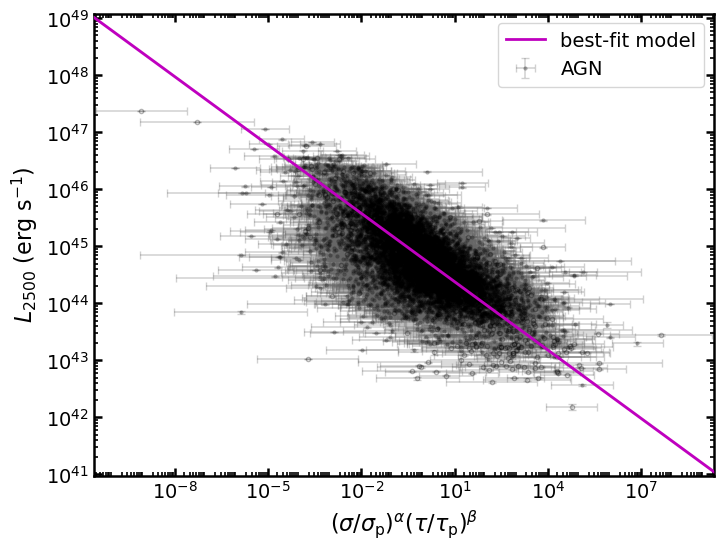

In [34]:
def plot_predicted_L2500_vs_sigmahat(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, debias=True, dms=None,
    show_residuals=False
):
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Indices & parameter names ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    def compute_xlog_and_err(params_arr, obs_arr, err_arr, pivots_array):
        M0_agn = params_arr[agn_model_pidx["M0_agn"]]
        predicted_M = M_model_agn(params_arr, obs_arr, pivots_array) - M0_agn
        x_log = predicted_M

        predited_M_err = M_model_agn_err(params_arr, obs_arr, err_arr, pivots_array)
        x_log_err = predited_M_err

        return x_log, x_log_err

    # --- Posterior medians (for cosmology & placing data in x) ---
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=results['H0'], Om0=results['Om0'], wp=results['wp'], wa=results['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'], wa=results['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=results['H0'], Om0=results['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # --- y-data: log10 L_2500 (with optional debias) ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        actual_M2500 = (d['apparent_mag_2500'] - dm_interp(pts)) - cosmo.distmod(d['z']).value
    else:
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = -0.4 * (actual_M2500 - 90.0)

    # y measurement uncertainty from apparent magnitudes (propagated into log10 L)
    y_log_meas_err = 0.4 * np.asarray(d['apparent_mag_2500_err'].fillna(0.0))

    # --- x for data (full predictor) ---
    median_params_arr = agn_model_pack_params(results)
    x_log_data, x_log_err_data = compute_xlog_and_err(median_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_data = 10**x_log_data
    x_lower = 10**(x_log_data - x_log_err_data)
    x_upper = 10**(x_log_data + x_log_err_data)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # --- Grid for model curves/band ---
    x_lo = np.percentile(x_log_data - x_log_err_data, 0) - 0.05
    x_hi = np.percentile(x_log_data + x_log_err_data, 100) + 0.05
    x_log_grid = np.linspace(x_lo, x_hi, 200)
    x_grid = 10**x_log_grid

    # --- Predict logL on grid for each posterior sample (we'll only use quantiles + median line) ---
    ylog_grid_by_sample = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        aparr = agn_model_pack_params(sample_params)
        M0 = aparr[agn_model_pidx["M0_agn"]]
        b = -0.4 * (M0 - 90.0)
        ylog_grid_by_sample.append(b + (-0.4) * x_log_grid)

    ylog_grid_by_sample = np.asarray(ylog_grid_by_sample)  # (nsamp, ngrid)
    ylog_med  = np.median(ylog_grid_by_sample, axis=0)
    ylog_low  = np.percentile(ylog_grid_by_sample, 16, axis=0)
    ylog_high = np.percentile(ylog_grid_by_sample, 84, axis=0)
    y_hi = np.max(ylog_high) + 0.05
    y_lo = np.min(ylog_low)  - 0.05

    # --- Residuals vs median model (log space) ---
    f_med  = interp1d(x_log_grid, ylog_med,  bounds_error=False, fill_value='extrapolate')
    f_low  = interp1d(x_log_grid, ylog_low,  bounds_error=False, fill_value='extrapolate')
    f_high = interp1d(x_log_grid, ylog_high, bounds_error=False, fill_value='extrapolate')

    model_logL_at_data = f_med(x_log_data)
    residuals = actual_logL2500 - model_logL_at_data

    # Error budget in log space for residuals: model spread + x-prop + mag error
    obs_err = 0.5 * (f_high(x_log_data) - f_low(x_log_data))
    propagated_err = 0.4 * np.abs(x_log_err_data)
    total_err = np.sqrt(obs_err**2 + propagated_err**2 + y_log_meas_err**2)

    # --- Figure scaffold ---
    color = 'm'
    if show_residuals:
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_res = None

    # --- Data with x & y error bars (y errors converted to linear space) ---
    key = 'alpha_lambda'
    color_key = d[key] if key in d.columns else np.zeros(len(d))
    yerr_linear = 10**actual_logL2500 * np.log(10) * y_log_meas_err

    # Solid vs open AGN markers by z (both main and inset)
    mask_in  = d["z"].between(0.44, 3.16)
    mask_out = ~mask_in

    # AGN (inside)
    ax.errorbar(
        x_data[mask_in], 10**actual_logL2500[mask_in], xerr=xerr_asym[:, mask_in], yerr=yerr_linear[mask_in],
        fmt='o', linestyle='none', markersize=3,
        mfc="black", mec="none",
        ecolor="#666666", elinewidth=1.1,
        alpha=0.3, zorder=0, label="AGN"
    )
    # AGN (outside, open)
    ax.errorbar(
        x_data[mask_out], 10**actual_logL2500[mask_out], xerr=xerr_asym[:, mask_out], yerr=yerr_linear[mask_out],
        fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.3,
        ecolor="#666666", elinewidth=1.1, zorder=0
    )

    # ax.scatter(
    #     x_data, 10**actual_logL2500,
    #     s=12, c="black", marker="o", edgecolors="none", alpha=0.8, zorder=1, label="AGN"
    # )
    # ax.errorbar(
    #     x_data, 10**actual_logL2500, xerr=xerr_asym, yerr=yerr_linear,
    #     fmt='none', linestyle='none',
    #     ecolor="#666666", elinewidth=1.1,
    #     alpha=0.3, zorder=0
    # )
    # --- Model: one line (median) + 68% band ---
    ax.fill_between(x_grid, 10**ylog_low, 10**ylog_high, color=color, alpha=0.18, zorder=9,)
    ax.plot(x_grid, 10**ylog_med, color=color, lw=2.0, zorder=10, label='best-fit model')

    # --- Axes & labels ---
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_xlim((3e-7, 7e5))
    # ax.set_ylim((7e41, 2e47))
    ax.set_xlim((10**x_lo, 10**x_hi))
    ax.set_ylim((10**y_lo, 10**y_hi))
    
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))


    ax.legend()

    if show_residuals and ax_res is not None:
        sc = ax_res.scatter(x_data, residuals, s=10, alpha=0.7, c=color_key, cmap='bwr',
                            edgecolor='k', lw=0.5, zorder=5)
        cbar = plt.colorbar(sc, ax=ax_res, orientation='vertical'); cbar.set_label(key)
        ax_res.errorbar(x_data, residuals, yerr=total_err,
                        fmt='none', alpha=0.25, lw=1.2, capsize=2.5, capthick=1, color='k', zorder=4)
        ax_res.axhline(0, color=color, linestyle='--', zorder=3)
        ax_res.set_ylabel('Residuals (log)')
        ax_res.set_xlabel(r'$x=\sigma^\alpha\,\tau^\beta\,10^{\gamma\,\mathrm{logistic}(\alpha_\nu)}$')
        ax_res.set_xscale('log')
        ax_res.set_ylim(-2.2, 2.2)
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel(r'$(\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')
        plt.setp(ax.get_xticklabels(), visible=True)


    os.makedirs(plot_path, exist_ok=True)
    os.makedirs(os.path.join(plot_path, "pdf"), exist_ok=True)
    if debias:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band_debiased.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)
    else:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band.pdf"), dpi=600)

    if show:
        plt.show()
    plt.close()

plot_predicted_L2500_vs_sigmahat(
    flat_samples_w0wa, df_agn, cosmo_model_w0wa, z_pivot_agn,
    plot_path='plots/hubble', show=True, debias=True, dms=dmag_corr_w0wa,
    show_residuals=False
)

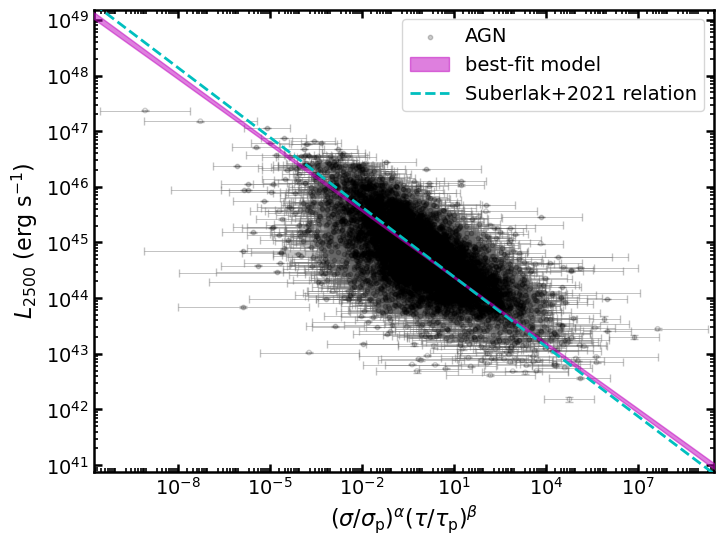

In [105]:
def plot_predicted_L2500_vs_sigmahat(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, debias=True, dms=None,
    show_residuals=False
):
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Indices & parameter names ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    # Helper: posterior median dict
    med_params = {k: np.median(flat_samples[:, param_indices[k]]) for k in model_labels}

    # --- Cosmology from medians (only for placing the *data* on y) ---
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=med_params['H0'], Om0=med_params['Om0'], w0=med_params['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=med_params['H0'], Om0=med_params['Om0'],
                            wp=med_params['wp'], wa=med_params['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=med_params['H0'], Om0=med_params['Om0'],
                            w0=med_params['w0'], wa=med_params['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=med_params['H0'], Om0=med_params['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # --- y-data: log10 L_2500 (with optional de-bias of apparent magnitudes) ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        actual_M2500 = (d['apparent_mag_2500'] - dm_interp(pts)) - cosmo.distmod(d['z']).value
    else:
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = convert_M2500_to_logL2500(actual_M2500)

    # y measurement uncertainty propagated to log10 L
    y_log_meas_err = 0.4 * np.asarray(d['apparent_mag_2500_err'].fillna(0.0))

    # --- Reference x (built at POSTERIOR-MEDIAN params) ---
    # This is the "common" axis we’ll plot against. It fixes the x definition,
    # then each posterior draw is *refit* onto this axis (slope+intercept).
    med_arr = agn_model_pack_params(med_params)
    M0_med = med_arr[agn_model_pidx["M0_agn"]]
    # predicted_M_ref = (M_model - M0) evaluated at median params → this is the "x in M-space"
    x_log_ref = M_model_agn(med_arr, agn_obs_arr, agn_pivot_arr) - M0_med
    x_ref = 10.0 ** x_log_ref

    # --- x for the plotted points (computed at med params for consistency with x_ref) ---
    x_data = x_ref
    # Propagate x errors from median params (same as before)
    pred_M_err_med = M_model_agn_err(med_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_lower = 10.0 ** (x_log_ref - pred_M_err_med)
    x_upper = 10.0 ** (x_log_ref + pred_M_err_med)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # Center of mass in the *reference* x (we’ll use this for plotting & band widening)
    xcm = np.mean(x_log_ref)
    var_x = np.var(x_log_ref, ddof=1)
    if not np.isfinite(var_x) or var_x <= 0:
        # Fallback (shouldn't normally happen)
        var_x = np.var(x_log_ref) + 1e-8

    # --- Grid in reference x (log space), padded a bit beyond the data ---
    # include lowest left error and highest right error
    x_min_err = np.min(x_log_ref - pred_M_err_med)
    x_max_err = np.max(x_log_ref + pred_M_err_med)

    x_lo = x_min_err - 0.20
    x_hi = x_max_err + 0.20

    x_log_grid = np.linspace(x_lo, x_hi, 250)
    x_grid = 10.0 ** x_log_grid

    # ---------- KEY CHANGE: build distribution in M first, *per sample*, then map to L ----------
    # For each posterior sample:
    #   1) Compute the sample's predicted M_i for every object:  M_i^s = M_model_agn(s)  (full model)
    #   2) Regress M_i^s against *reference* x_log_ref: M_i^s ≈ c_s + k_s * x_log_ref   (OLS)
    #   3) Predict M on the grid: M_grid^s = c_s + k_s * x_log_grid
    #   4) Convert to L: logL_grid^s = -0.4*(M_grid^s - 90)
    #
    # Because k_s varies across samples, the spread grows as |x - x_cm| increases.
    ylog_grid_by_sample = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        s_arr = agn_model_pack_params(sample_params)

        # Full model (M) for each object at this draw
        M_i = M_model_agn(s_arr, agn_obs_arr, agn_pivot_arr)     # shape (N,)
        # OLS onto the *fixed* reference x
        xc = xcm
        Mc = np.mean(M_i)
        cov_Mx = np.mean((x_log_ref - xc) * (M_i - Mc))
        k_s = cov_Mx / var_x                     # slope in M-space against x_ref
        c_s = Mc - k_s * xc                      # intercept

        # Predict M on grid, then map to L
        M_grid_s = c_s + k_s * x_log_grid
        ylog_grid_s = -0.4 * (M_grid_s - 90.0)   # convert slope & intercept to L-space
        ylog_grid_by_sample.append(ylog_grid_s)

    ylog_grid_by_sample = np.asarray(ylog_grid_by_sample)  # (nsamp, ngrid)

    # Pointwise posterior summaries for the band
    ylog_med  = np.median(ylog_grid_by_sample, axis=0)
    ylog_low  = np.percentile(ylog_grid_by_sample, 16, axis=0)
    ylog_high = np.percentile(ylog_grid_by_sample, 84, axis=0)
    y_hi = np.max(ylog_high) + 0.05
    y_lo = np.min(ylog_low)  - 0.05

    # --- x for the plotted points (computed at med params for consistency with x_ref) ---
    x_data = x_ref
    # Propagate x errors from median params (same as before)
    pred_M_err_med = M_model_agn_err(med_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_lower = 10.0 ** (x_log_ref - pred_M_err_med)
    x_upper = 10.0 ** (x_log_ref + pred_M_err_med)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # --- Residuals vs median line (log space) for optional panel ---
    f_med  = interp1d(x_log_grid, ylog_med,  bounds_error=False, fill_value='extrapolate')
    f_low  = interp1d(x_log_grid, ylog_low,  bounds_error=False, fill_value='extrapolate')
    f_high = interp1d(x_log_grid, ylog_high, bounds_error=False, fill_value='extrapolate')

    model_logL_at_data = f_med(x_log_ref)
    residuals = actual_logL2500 - model_logL_at_data

    # Error budget in log space for residuals: model spread + x-prop + mag error
    obs_err = 0.5 * (f_high(x_log_ref) - f_low(x_log_ref))
    propagated_err = 0.4 * np.abs(pred_M_err_med)
    total_err = np.sqrt(obs_err**2 + propagated_err**2 + y_log_meas_err**2)

    # --- Figure scaffold ---
    color = 'm'
    if show_residuals:
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_res = None

    # --- Data with errors (y errors converted to linear space) ---
    key = 'alpha_lambda'
    color_key = d[key] if key in d.columns else np.zeros(len(d))
    yerr_linear = 10**actual_logL2500 * np.log(10) * y_log_meas_err

    # Solid vs open AGN markers by z (both main and inset)
    mask_in  = d["z"].between(0.44, 3.16)
    mask_out = ~mask_in

    # # AGN (inside)
    # ax.errorbar(
    #     x_data[mask_in], 10**actual_logL2500[mask_in], xerr=xerr_asym[:, mask_in], yerr=yerr_linear[mask_in],
    #     fmt='o', linestyle='none', markersize=3,
    #     mfc="black", mec="none",
    #     ecolor="#666666", elinewidth=1.1,
    #     alpha=0.3, zorder=0, label="AGN"
    # )
    # # AGN (outside, open)
    # ax.errorbar(
    #     x_data[mask_out], 10**actual_logL2500[mask_out], xerr=xerr_asym[:, mask_out], yerr=yerr_linear[mask_out],
    #     fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.3,
    #     ecolor="#666666", elinewidth=1.1, zorder=0
    # )

    ax.errorbar(
        x_data, 10**actual_logL2500, xerr=xerr_asym, yerr=yerr_linear,
        fmt="none", ecolor="#666666", elinewidth=0.7, alpha=0.4, zorder=2
    )

    # AGN (inside)
    ax.scatter(x_data[mask_in], 10**actual_logL2500[mask_in],
                c='k', s=10, alpha=0.2, edgecolors="k", zorder=3,
                label="AGN"
                #label="AGN (0.44 < z < 3.16)"
    )
    # AGN (outside)
    ax.scatter(x_data[mask_out], 10**actual_logL2500[mask_out],
                c='none', s=10, alpha=0.2, edgecolors="k", zorder=3,
                #label="AGN (z < 0.44 or z > 3.16)"
    )

    # --- Model: heteroscedastic ribbon (from varying slopes) + median line ---
    ax.fill_between(x_grid, 10**ylog_low, 10**ylog_high, color=color, alpha=0.5, label='best-fit model', zorder=9)
    #ax.plot(x_grid, 10**ylog_med, color=color, lw=2.0, zorder=10, label='best-fit model')

    A = 2.515 - 0.543
    B = 0.17 - 0.479
    C = 0.042 + 0.125
    D = 0.127 + 0.104
    log_MBH = 0
    log_lam = 0
    L_scale = np.mean(10**actual_logL2500) # /(A + C*(23+90) + D*log_MBH + B*log_lam) * Mi -> M2500
    L_suberlak = L_scale * x_grid**(-2.5*C) * (2.5*C) 
    ax.plot(x_grid, L_suberlak, color='c', lw=2.0, zorder=10, label='Suberlak+2021 relation', linestyle='--')
 
 
 
    # --- Axes & labels ---
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim((10**x_lo, 10**x_hi))
    ax.set_ylim((10**y_lo, 10**y_hi))
    # ax.set_xlim((1e-9, 1e7))
    # ax.set_ylim((1e41, 1e49))
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
    ax.legend(loc='upper right')

    if show_residuals and ax_res is not None:
        sc = ax_res.scatter(x_data, residuals, s=10, alpha=0.7, c=color_key, cmap='bwr',
                            edgecolor='k', lw=0.5, zorder=5)
        cbar = plt.colorbar(sc, ax=ax_res, orientation='vertical'); cbar.set_label(key)
        ax_res.errorbar(x_data, residuals, yerr=total_err,
                        fmt='none', alpha=0.25, lw=1.2, capsize=2.5, capthick=1, color='k', zorder=4)
        ax_res.axhline(0, color=color, linestyle='--', zorder=3)
        ax_res.set_ylabel('Residuals (log)')
        ax_res.set_xlabel(r'$(\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')
        ax_res.set_xscale('log')
        ax_res.set_ylim(-2.2, 2.2)
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel(r'$(\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')
        plt.setp(ax.get_xticklabels(), visible=True)

    os.makedirs(plot_path, exist_ok=True)
    os.makedirs(os.path.join(plot_path, "pdf"), exist_ok=True)
    if debias:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band_debiased.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)
    else:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band.pdf"), dpi=600)

    if show:
        plt.show()
    plt.close()


plot_predicted_L2500_vs_sigmahat(
    flat_samples_w0wa, df_agn, cosmo_model_w0wa, z_pivot_agn,
    plot_path='plots/hubble', show=True, debias=True, dms=dmag_corr_w0wa,
    show_residuals=False
)

In [132]:
import math
from typing import Tuple, Optional

def _round_sig(x: float, sig: int) -> float:
    if x == 0 or not math.isfinite(x):
        return x
    return round(x, -int(math.floor(math.log10(abs(x)))) + (sig - 1))

def format_value_uncertainty(
    median: float,
    err: Optional[float] = None,
    *,
    twosig_when=(1, 2, 3),
    sci: bool = True,
    latex: bool = True,
    unit: Optional[str] = None,
    max_decimals_no_sci: int = 2,          # <- cap decimals in non-sci mode
    prefer_fewer_decimals: bool = True     # <- use 1 sig fig if 2 would exceed the cap
) -> Tuple[float, Optional[float], int, str]:
    """
    Returns (value_rounded, err_rounded, exponent, formatted_string).
    - Uncertainty: 1 sig fig, except 2 when leading digit in twosig_when,
      but if that would exceed `max_decimals_no_sci` in non-sci mode, fall back to 1.
    - Value rounded to same decimal place as the (rounded) uncertainty.
    - No '±' when err is None.
    - Avoid sci for 0.1 <= |value| < 10 (plain decimals).
    - Special-case: fold 1×10^{-1} or 1×10^{-2} into 0.1 / 0.01.
    """
    # choose exponent (initial)
    if median == 0 or not math.isfinite(median):
        exponent = 0
    else:
        exponent = int(math.floor(math.log10(abs(median)))) if sci else 0

    # avoid sci in [0.1, 10)
    if sci and 0.1 <= abs(median) < 10:
        exponent = 0

    scale = 10.0 ** exponent if exponent != 0 else 1.0
    v = median / scale

    def decimals_needed(x: float) -> int:
        if x == 0: return 0
        return max(0, -int(math.floor(math.log10(abs(x)))))  # e.g. 0.02 -> 2

    if err is None:
        v_rounded = _round_sig(v, 3) if exponent != 0 else _round_sig(v, 3)
        e_rounded = None
    else:
        if err < 0 or not math.isfinite(err):
            raise ValueError("err must be finite and non-negative.")
        e = err / scale

        if e == 0:
            e_rounded = 0.0
            v_rounded = round(v, 6)
        else:
            # candidate with 2 sig figs?
            e1 = _round_sig(e, 1)
            lead = int(abs(e1) / (10 ** math.floor(math.log10(abs(e1)))))
            use_two = lead in twosig_when

            # if non-sci and two sig figs would exceed decimal cap, fall back to 1
            if use_two:
                e_two = _round_sig(e, 2)
                if exponent == 0 and prefer_fewer_decimals and decimals_needed(e_two) > max_decimals_no_sci:
                    use_two = False

            sig_unc = 2 if use_two else 1
            e_rounded = _round_sig(e, sig_unc)

            # round value to same decimal place as e_rounded
            digits = decimals_needed(e_rounded)
            v_rounded = round(v, digits)

            # re-enforce after potential order change
            e_rounded = _round_sig(e, sig_unc)
            digits = decimals_needed(e_rounded)
            v_rounded = round(v, digits)

    # special-case: (±)1×10^{-1 or -2} -> fold to decimal
    if sci and exponent in (-1, -2) and (abs(v_rounded) == 1.0):
        v_rounded *= 10 ** exponent
        if err is not None:
            e_rounded *= 10 ** exponent
        exponent = 0
        scale = 1.0

    # build string
    if latex:
        if exponent != 0:
            s = (f"{v_rounded}\\times 10^{{{exponent}}}"
                 if err is None else f"({v_rounded} \\pm {e_rounded})\\times 10^{{{exponent}}}")
        else:
            s = (f"{v_rounded}" if err is None else f"{v_rounded} \\pm {e_rounded}")
        if unit:
            s += f"\\,\\mathrm{{{unit}}}"
    else:
        if exponent != 0:
            s = (f"{v_rounded}×10^{exponent}"
                 if err is None else f"({v_rounded} ± {e_rounded})×10^{exponent}")
        else:
            s = (f"{v_rounded}" if err is None else f"{v_rounded} ± {e_rounded}")
        if unit:
            s += f" {unit}"

    val_out = v_rounded * (10 ** exponent if exponent != 0 else 1.0)
    err_out = (e_rounded * (10 ** exponent) if (err is not None and exponent != 0) else (e_rounded if err is not None else None))
    
    return s
    return val_out, err_out, exponent, s



def write_results_tex_variables(df_agn, flat_samples, cosmo_model, compare_r, z_pivot_agn, write_path):
    """
    Write key cosmological parameters to a LaTeX file as \newcommand definitions.

    Parameters
    ----------
    flat_samples : (N, P) array
        Flattened MCMC samples: N total draws by P parameters.
    cosmo_model : str
        Cosmological model string.
    z_pivot_agn : float
        Pivot redshift for w0/wa conversion if applicable.
    write_path : str
        Directory path to write the LaTeX file (filename is 'cosmo_params.tex').
    """

    obs_arr, err_arr, pivots_arr = agn_model_pack_obs(df_agn)

    log_sigma_UV_pivot  = pivots_arr[agn_model_oidx["log_sigma_UV"]]
    log_tau_UV_RF_pivot = pivots_arr[agn_model_oidx["log_tau_UV_RF"]]


    priors, model_labels, _ = get_model_params(cosmo_model)
    flat_samples = np.asarray(flat_samples)

    results = {key: sym_percentile(flat_samples[:, i])
               for i, key in enumerate(model_labels)}

    # Write to LaTeX file
    lines = []
    lines.append(r"% Auto-generated cosmological parameters from MCMC samples")
    lines.append(r"% Do not edit by hand; regenerate with write_results_tex_variables()")
    lines.append(r"\newcommand{\resultNumAGN}{%d}" % len(df_agn))
    lines.append(r"\newcommand{\resultSigma}{\ensuremath{%s}}" % format_value_uncertainty(compare_r["sigma_from_odds_two_sided"], None))

    lines.append(r"\newcommand{\resultAlphaAGN}{\ensuremath{%s}}" % format_value_uncertainty(results['alpha_agn'][0], results['alpha_agn'][1]))
    lines.append(r"\newcommand{\resultBetaAGN}{\ensuremath{%s}}" % format_value_uncertainty(results['beta_agn'][0], results['beta_agn'][1]))

    lines.append(r"\newcommand{\resultSigmaUVPivot}{\ensuremath{%s}}" % format_value_uncertainty(10**log_sigma_UV_pivot, None))
    lines.append(r"\newcommand{\resultTauUVRFPivot}{\ensuremath{%s}}" % format_value_uncertainty(10**log_tau_UV_RF_pivot, None))



    M0_agn_samples = flat_samples[:, model_labels.index('M0_agn')]
    alpha_agn_samples = flat_samples[:, model_labels.index('alpha_agn')]
    beta_agn_samples = flat_samples[:, model_labels.index('beta_agn')]

    alpha_AGN_L_samples = alpha_agn_samples * (-1/2.5)
    beta_AGN_L_samples  = beta_agn_samples * (-1/2.5)
    L_intercept_samples = np.power(10, (90-M0_agn_samples)/2.5)

    L_intercept, L_intercept_err = sym_percentile(L_intercept_samples)
    val, err = L_intercept, L_intercept_err

    # --- Extract exponent from the value ---
    exp = int(np.floor(np.log10(abs(val)))) if val != 0 else 0
    scale = 10.0**exp

    mant_val = val / scale
    mant_err = err / scale

    lines.append(
        r"\newcommand{\resultLIntercept}{\ensuremath{%s}}" %
        format_value_uncertainty(*sym_percentile(L_intercept_samples), unit=r"erg\,s^{-1}")
    )

    lines.append(r"\newcommand{\resultAlphaAGNL}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(alpha_AGN_L_samples)))
    lines.append(r"\newcommand{\resultBetaAGNL}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(beta_AGN_L_samples)))

    hd_scatter_samples = np.exp(flat_samples[:, model_labels.index('log_f')])
    lines.append(r"\newcommand{\resultScatterHD}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(hd_scatter_samples), unit=r"mag"))

    l_scatter_samples = hd_scatter_samples / 2.5
    lines.append(r"\newcommand{\resultScatterL}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(l_scatter_samples), unit=r"dex"))


    tex_path = os.path.join(write_path, "param_results.tex")
    with open(tex_path, "w") as f:
        for line in lines:
            print(line)
            f.write(line + "\n")
    print(f"Wrote result parameters LaTeX commands to {tex_path}")

compare_r = {
    "sigma_from_odds_two_sided": 3.5
}
write_results_tex_variables(df_agn, flat_samples_w0wa, cosmo_model_w0wa, compare_r, 0, 'plots/hubble')


% Auto-generated cosmological parameters from MCMC samples
% Do not edit by hand; regenerate with write_results_tex_variables()
\newcommand{\resultNumAGN}{12185}
\newcommand{\resultSigma}{\ensuremath{3.5}}
\newcommand{\resultAlphaAGN}{\ensuremath{7.0 \pm 0.11}}
\newcommand{\resultBetaAGN}{\ensuremath{-3.12 \pm 0.05}}
\newcommand{\resultSigmaUVPivot}{\ensuremath{0.219}}
\newcommand{\resultTauUVRFPivot}{\ensuremath{6.42\times 10^{2}}}
\newcommand{\resultLIntercept}{\ensuremath{(6.0 \pm 0.22)\times 10^{44}\,\mathrm{erg\,s^{-1}}}}
\newcommand{\resultAlphaAGNL}{\ensuremath{-2.82 \pm 0.04}}
\newcommand{\resultBetaAGNL}{\ensuremath{1.25 \pm 0.019}}
\newcommand{\resultScatterHD}{\ensuremath{0.83 \pm 0.017\,\mathrm{mag}}}
\newcommand{\resultScatterL}{\ensuremath{0.33 \pm 0.007\,\mathrm{dex}}}
Wrote result parameters LaTeX commands to plots/hubble/param_results.tex


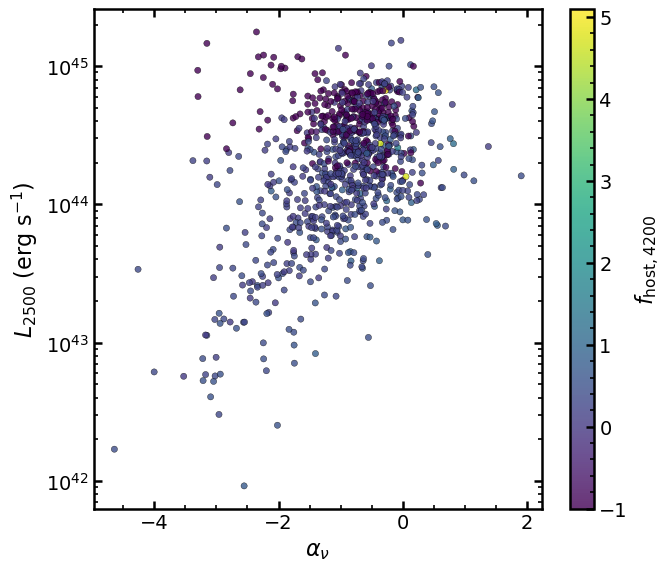

Saved plots/hubble/test/L2500_vs_alpha_nu.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

import numpy as np
import matplotlib.pyplot as plt
import os

def plot_L2500_vs_alpha_nu(df_agn, cosmo_model, z_pivot_agn,
                           plot_path='plots/hubble', show=False, debias=True, dms=None):
    d = df_agn.copy()

    # --- Build cosmology ---
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=70, Om0=0.3, w0=-1)   # set defaults if no posterior
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    else:
        raise ValueError("Add support for your cosmology model here")

    # --- Absolute magnitudes & debias ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
        M2500 -= dm_interp(pts)
    else:
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value

    logL2500 = -0.4 * (M2500 - 90.0)
    L2500 = 10**logL2500

    # --- Add computed L back into df for masking ---
    d = d.assign(L2500=L2500, logL2500=logL2500)

    # --- Now apply mask on f_host_4200 ---
    d = d[d['f_host_4200'] > -2].reset_index(drop=True)

    # --- Scatter plot ---
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(d['alpha_nu'], d['L2500'], c=d['f_host_4200'], cmap='viridis',
                    s=20, alpha=0.8, edgecolor='k', lw=0.3)

    cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
    cbar.set_label(r'$f_{\rm host,4200}$')

    ax.set_xlabel(r'$\alpha_\nu$')
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_yscale('log')

    plt.tight_layout()
    os.makedirs(plot_path, exist_ok=True)
    outfile = os.path.join(plot_path, "L2500_vs_alpha_nu.png")
    plt.savefig(outfile, dpi=300)
    if show:
        plt.show()
    plt.close()
    print(f"Saved {outfile}")

plot_L2500_vs_alpha_nu(df_agn, cosmo_model="FlatwCDM", z_pivot_agn=1.5, debias=True, dms=dmag_corr, show=True, plot_path='plots/hubble/test')